In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df= pd.read_csv('/content/disease_prediction.csv')

In [4]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [6]:
df['disease'].value_counts()

,count
disease,
Yes,501
No,499


In [7]:
df= df.drop('patient_id',axis=1)

In [8]:
X=df.drop('disease',axis=1)
y=df['disease']

In [9]:
X=pd.get_dummies(X, drop_first=True)
X.head()

,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,gender_Male,smoking_Yes,alcohol_consumption_Yes,physical_activity_Low,physical_activity_Medium,family_history_Yes
0,32,101,235,152,79,28.5,73,True,False,True,True,False,True
1,31,124,191,134,77,33.9,71,True,False,True,True,False,True
2,45,57,141,114,71,27.2,79,True,True,True,True,False,False
3,75,69,268,120,82,21.5,61,False,True,True,False,True,False
4,53,107,163,131,75,23.3,73,True,True,False,True,False,True


In [10]:
X=X.astype(int)
X.head()

,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,gender_Male,smoking_Yes,alcohol_consumption_Yes,physical_activity_Low,physical_activity_Medium,family_history_Yes
0,32,101,235,152,79,28,73,1,0,1,1,0,1
1,31,124,191,134,77,33,71,1,0,1,1,0,1
2,45,57,141,114,71,27,79,1,1,1,1,0,0
3,75,69,268,120,82,21,61,0,1,1,0,1,0
4,53,107,163,131,75,23,73,1,1,0,1,0,1


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)


LogisticRegression()

In [14]:
y_pred=model.predict(X_test)
y_pred[:10]

array(['No', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'],
      dtype=object)

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.86

In [16]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

          No       0.85      0.90      0.87       105
         Yes       0.88      0.82      0.85        95

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



array([[94, 11],
       [17, 78]])

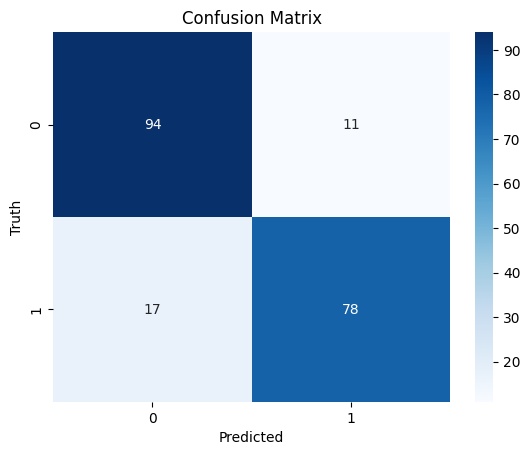

In [22]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True , fmt='d' , cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()